In [1]:
from xrss.dataloader import XRayDataset, show_images_and_bboxes
from xrss.utils import evaluate_score, xyxy_to_yolo, yolo_to_xyxy, compute_iou
from xrss.models import RandomForestDetector


from tqdm import tqdm
import itertools
import pandas as pd
import cv2
import numpy as np

In [2]:
yaml_file = "../xray_data/data.yaml"

train_dataset = XRayDataset(yaml_file, split="train")
val_dataset = XRayDataset(yaml_file, split="val")

In [3]:
model = RandomForestDetector(img_size=416)

model.train(train_dataset)

Training on 4200 images (Extraction will take a moment)...


Building Feature Set: 100%|██████████| 4200/4200 [00:09<00:00, 447.99it/s]


Training Complete. Learned 6215 samples.
Feature Importance (Aspect Ratio, Area, Solidity): [0.27849154 0.40496335 0.3165451 ]


Displaying sample images with ground truth bounding boxes:


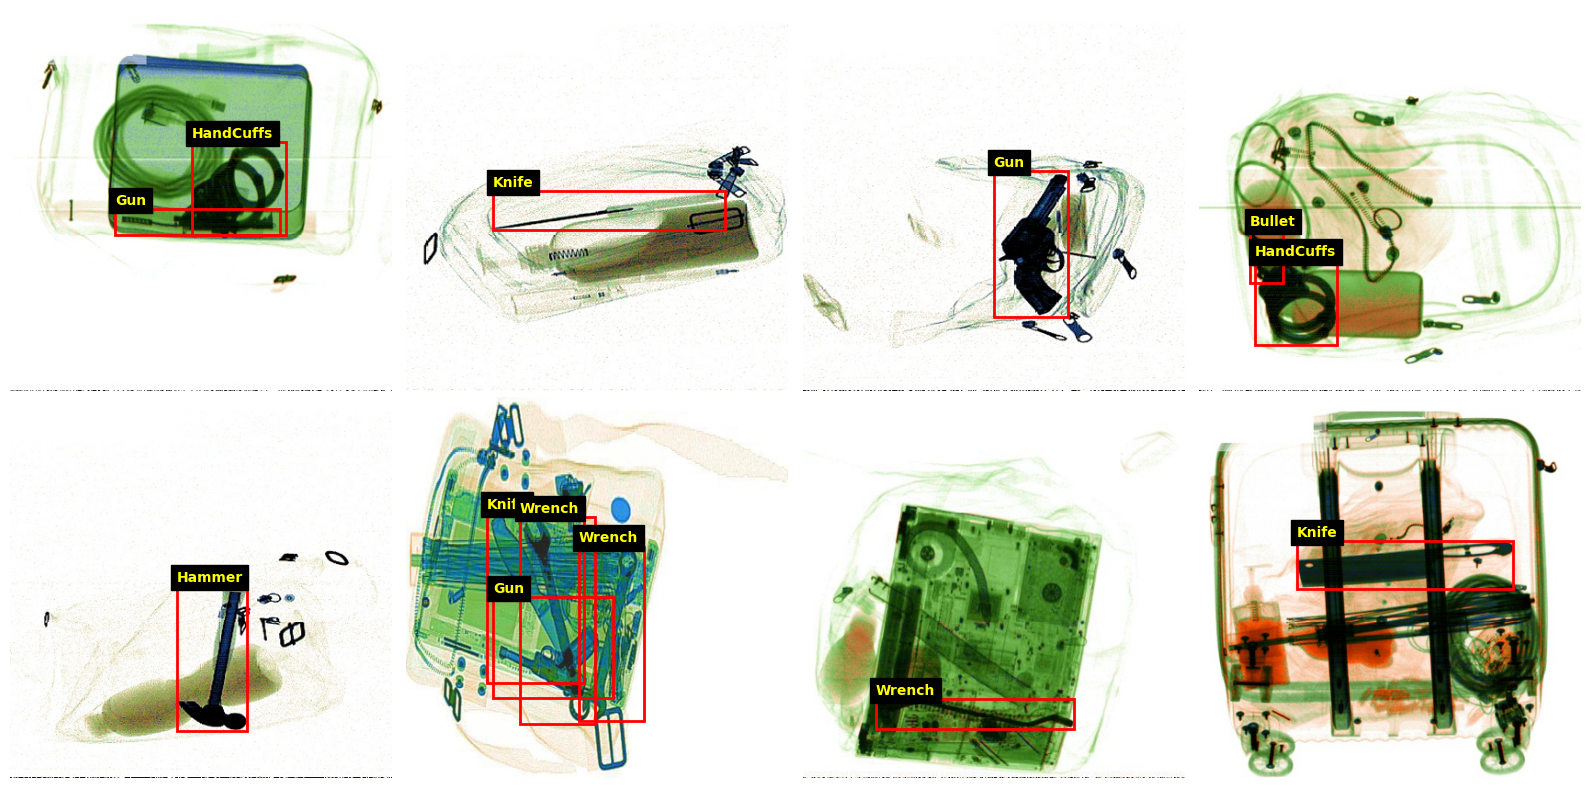

Displaying sample images with predicted bounding boxes:


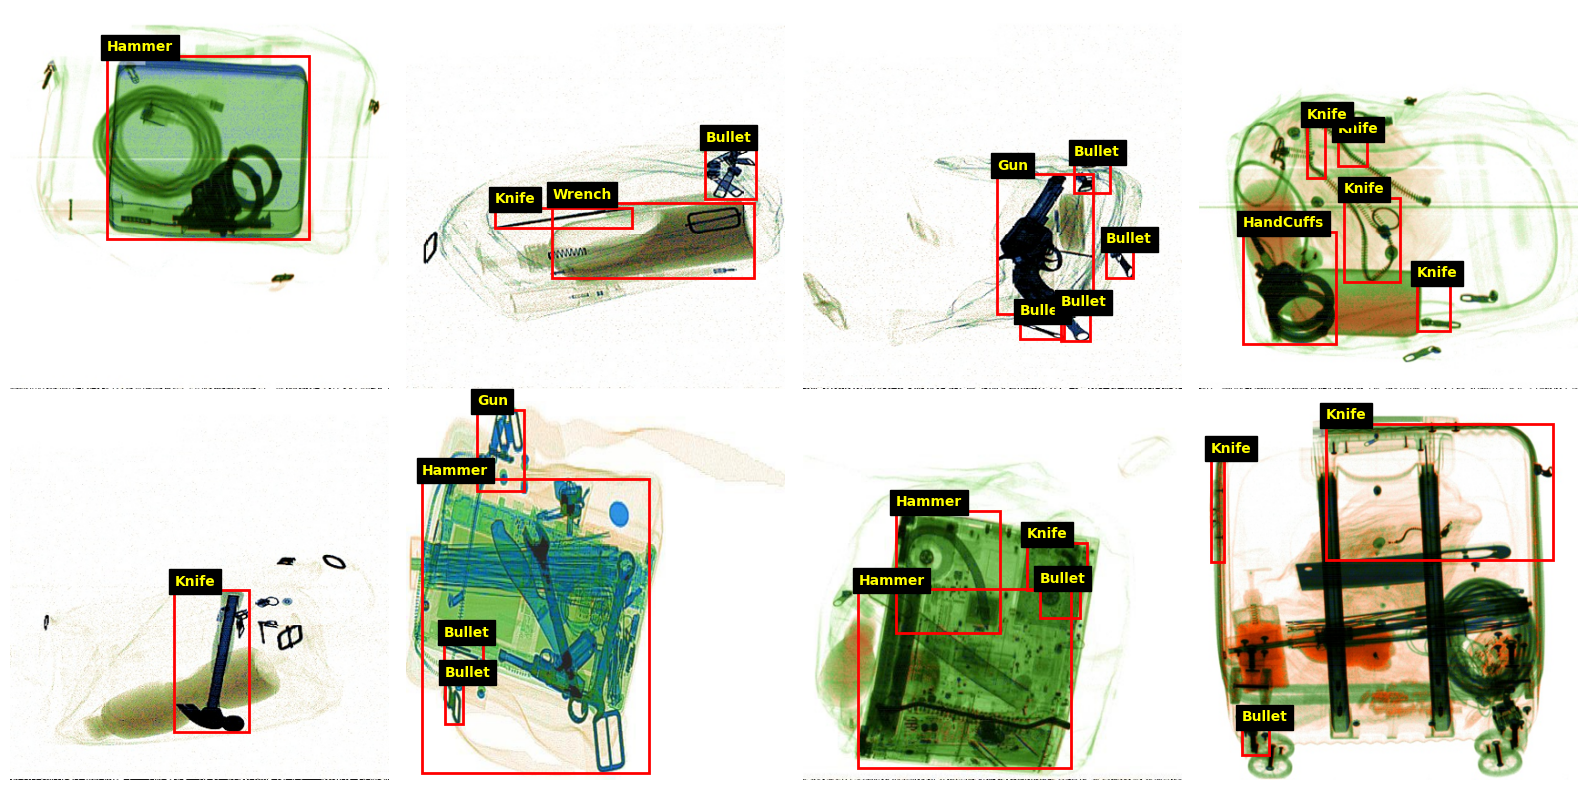

In [4]:
indexes = list(range(8))

images = [train_dataset[i][0] for i in indexes]
labels = [train_dataset[i][1] for i in indexes]

print("Displaying sample images with ground truth bounding boxes:")
show_images_and_bboxes(train_dataset, images, labels, cols=4)

preds = []
for img in images:
    # Unpack the tuple!
    # _ ignores the binary_mask since the visualizer doesn't need it
    boxes = model.detect(img)

    preds.append(boxes)

print("Displaying sample images with predicted bounding boxes:")
show_images_and_bboxes(train_dataset, images, preds, cols=4)